1.
A partir da imagem original obtenha as outras imagens conforme descrição
Desejamos separar linhas de círculos. Uma operação de abertura com um elemento estruturante na forma de círculo (definir o raio) faz essa tarefa. Gere uma imagem com os círculos e uma com as linhas

In [66]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("art3.png", cv2.IMREAD_GRAYSCALE)
_, img1_bin = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)

ABERTURA MORFOLÓGICA

In [67]:
raio = 6  
diametro = 2 * raio + 1

elemento_circular = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (diametro, diametro))

print("Elemento estruturante (formato circular):")
print(elemento_circular)

Elemento estruturante (formato circular):
[[0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0]]


1. IMAGEM COM APENAS OS CÍRCULOS (via abertura)

In [68]:
img_circulos = cv2.morphologyEx(img1_bin, cv2.MORPH_OPEN, elemento_circular)

2. IMAGEM COM APENAS AS LINHAS (via subtração)

In [69]:
img_linhas = cv2.subtract(img1_bin, img_circulos)

VISUALIZAÇÃO DOS RESULTADOS

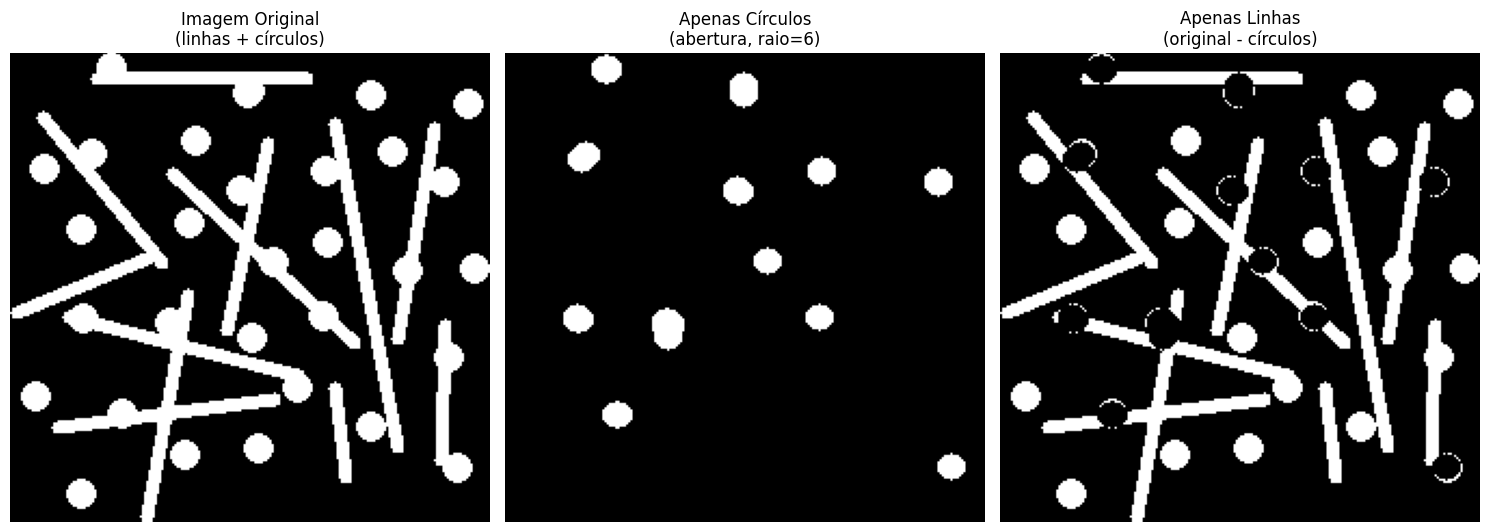


Pixels brancos na original: 10715
Pixels brancos nos círculos: 1756
Pixels brancos nas linhas: 8959


In [70]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img1_bin, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Imagem Original\n(linhas + círculos)")

axs[1].imshow(img_circulos, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(f"Apenas Círculos\n(abertura, raio={raio})")

axs[2].imshow(img_linhas, cmap='gray', vmin=0, vmax=255)
axs[2].set_title("Apenas Linhas\n(original - círculos)")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Informações adicionais
print(f"\nPixels brancos na original: {np.sum(img1_bin == 255)}")
print(f"Pixels brancos nos círculos: {np.sum(img_circulos == 255)}")
print(f"Pixels brancos nas linhas: {np.sum(img_linhas == 255)}")

2. 
a. Obter linhas verticais. Abertura com elemento estruturante vertical 3x9 b) Obter linhas horizontais. Abertura com elemento estruturante horizontal 9x3. Tente eliminar as linhas erradas usando uma máscara maior

In [71]:
img2 = cv2.imread("art2.png", cv2.IMREAD_GRAYSCALE)
_, img2_bin = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

1. LINHAS VERTICAIS - Abertura com elemento 3x9 (largura x altura)

In [72]:
elemento_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 9))

print("Elemento estruturante vertical (3x9):")
print(elemento_vertical)

img_verticais = cv2.morphologyEx(img2_bin, cv2.MORPH_OPEN, elemento_vertical)

Elemento estruturante vertical (3x9):
[[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]]


2. LINHAS HORIZONTAIS - Abertura com elemento 9x3 (largura x altura)

In [73]:
elemento_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))

print("\nElemento estruturante horizontal (9x3):")
print(elemento_horizontal)

img_horizontais = cv2.morphologyEx(img2_bin, cv2.MORPH_OPEN, elemento_horizontal)


Elemento estruturante horizontal (9x3):
[[1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]]


VISUALIZAÇÃO INICIAL

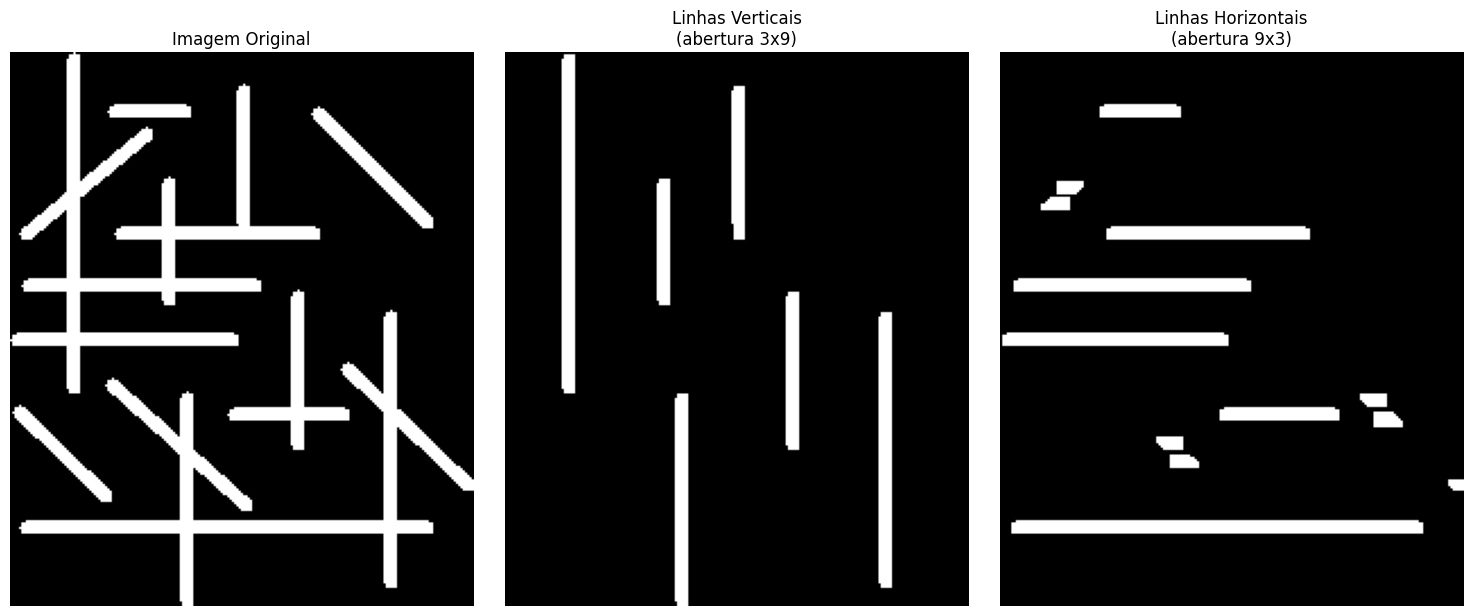

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img2_bin, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Imagem Original")

axs[1].imshow(img_verticais, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("Linhas Verticais\n(abertura 3x9)")

axs[2].imshow(img_horizontais, cmap='gray', vmin=0, vmax=255)
axs[2].set_title("Linhas Horizontais\n(abertura 9x3)")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

ELIMINANDO LINHAS ERRADAS

In [75]:
elemento_vertical_grande = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 15))
img_verticais_v2 = cv2.morphologyEx(img2_bin, cv2.MORPH_OPEN, elemento_vertical_grande)

elemento_horizontal_grande = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
img_horizontais_v2 = cv2.morphologyEx(img2_bin, cv2.MORPH_OPEN, elemento_horizontal_grande)


VISUALIZAÇÃO COMPARATIVA

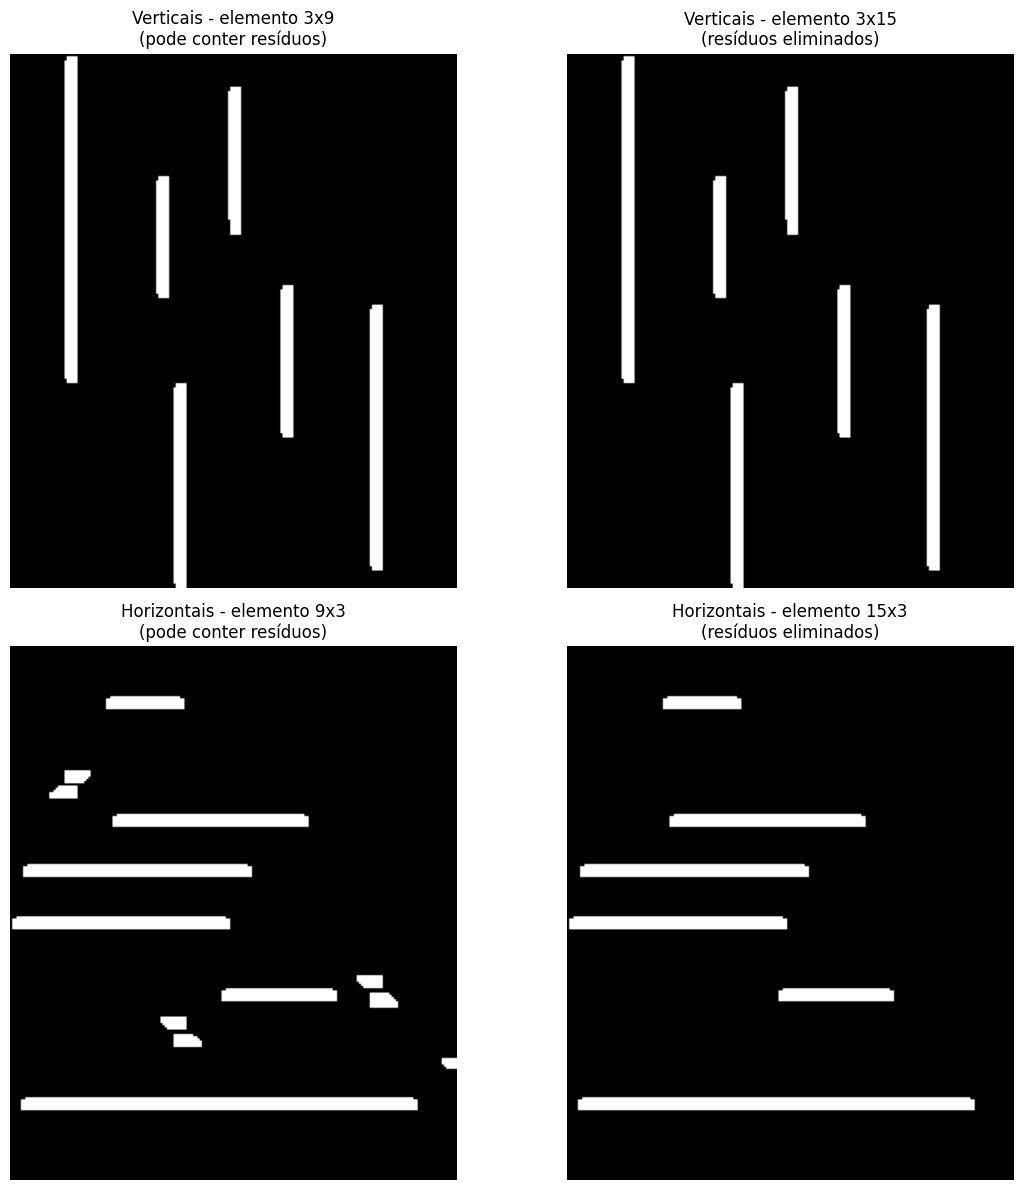

In [76]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0, 0].imshow(img_verticais, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Verticais - elemento 3x9\n(pode conter resíduos)")

axs[0, 1].imshow(img_verticais_v2, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title("Verticais - elemento 3x15\n(resíduos eliminados)")

axs[1, 0].imshow(img_horizontais, cmap='gray', vmin=0, vmax=255)
axs[1, 0].set_title("Horizontais - elemento 9x3\n(pode conter resíduos)")

axs[1, 1].imshow(img_horizontais_v2, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title("Horizontais - elemento 15x3\n(resíduos eliminados)")

for ax in axs.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


3.
a. Theshold (t=210)
b. Utilizando abertura com elemento circular de 11 pixels para reter as células grandes
c. É possível reter somente os objetos pequenos utilizando a operação abertura?

In [77]:
img3 = cv2.imread("cel4.png", cv2.IMREAD_GRAYSCALE)

a. THRESHOLD (t = 210)

In [78]:
limiar = 210
_, img3_bin = cv2.threshold(img3, limiar, 255, cv2.THRESH_BINARY_INV)

b. ABERTURA COM ELEMENTO CIRCULAR

In [79]:
raio = 11
diametro = 2 * raio + 1
elemento_circular = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (diametro, diametro))

img3_abertura = cv2.morphologyEx(img3_bin, cv2.MORPH_OPEN, elemento_circular)

VISUALIZAÇÃO (a) e (b)

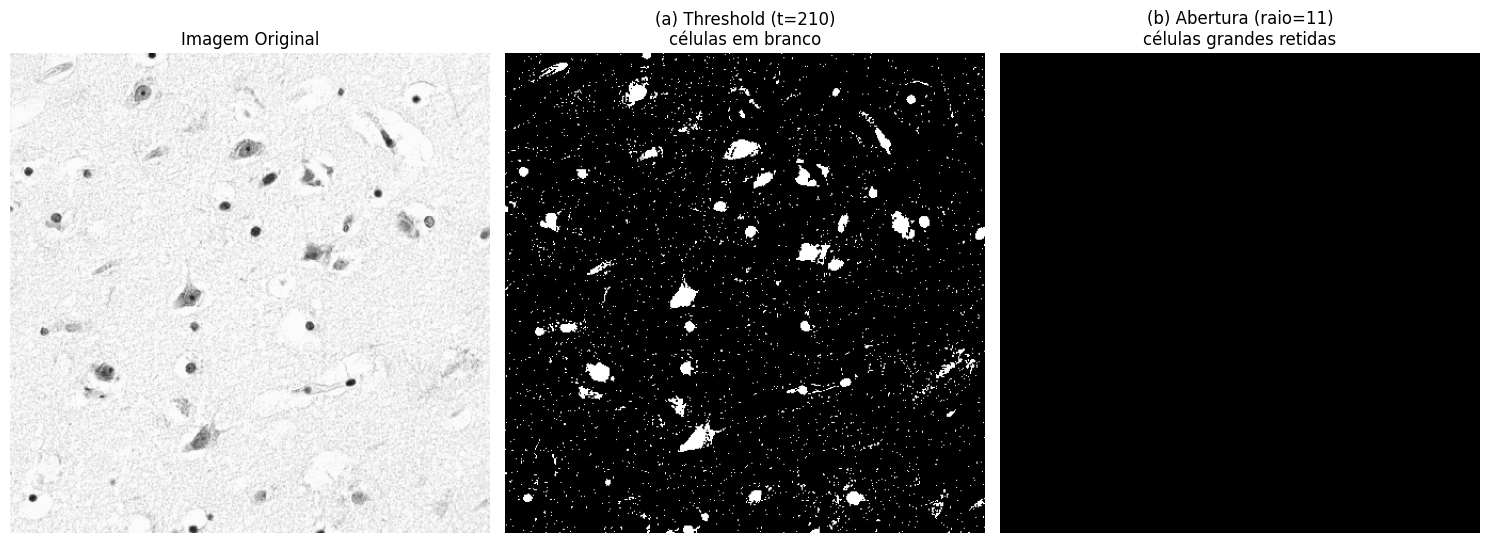

In [80]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img3, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Imagem Original")

axs[1].imshow(img3_bin, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(f"(a) Threshold (t={limiar})\ncélulas em branco")

axs[2].imshow(img3_abertura, cmap='gray', vmin=0, vmax=255)
axs[2].set_title(f"(b) Abertura (raio={raio})\ncélulas grandes retidas")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()


c. É POSSÍVEL RETER SOMENTE OS OBJETOS PEQUENOS COM ABERTURA?
    RESPOSTA: Não diretamente, apenas obtendo os objetos pequenos por SUBTRAÇÃO

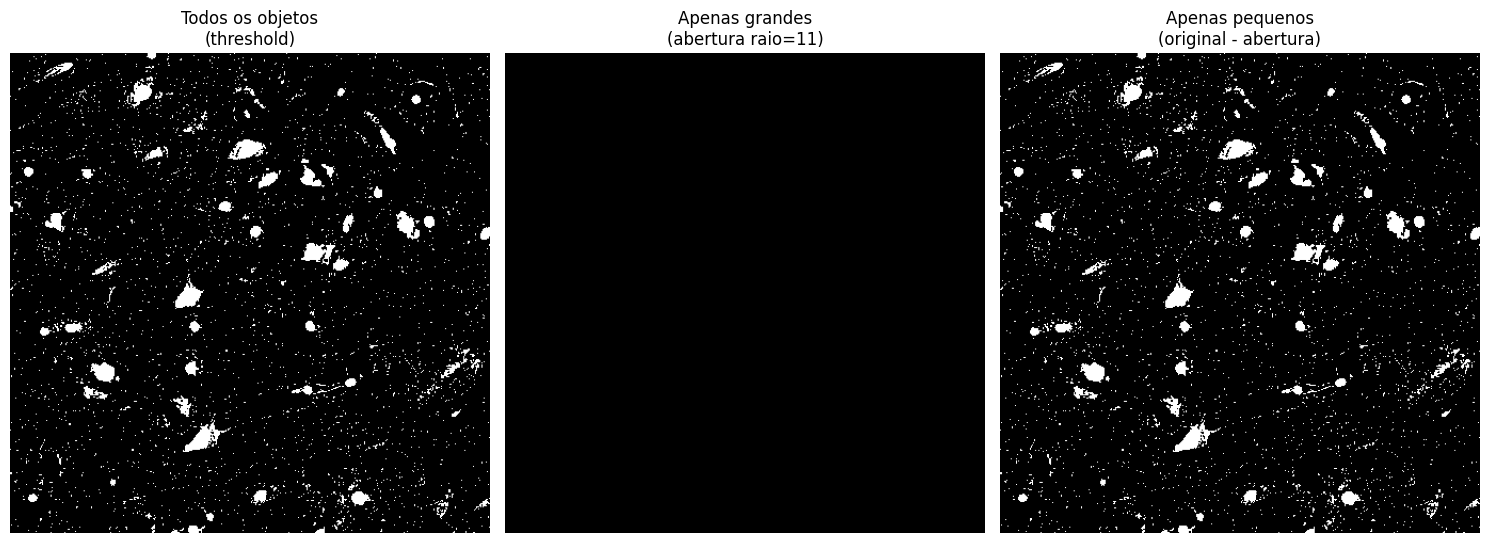

In [81]:
img3_objetos_pequenos = cv2.subtract(img3_bin, img3_abertura)

fig, axs = plt.subplots(1, 3, figsize=(15, 6))

axs[0].imshow(img3_bin, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Todos os objetos\n(threshold)")

axs[1].imshow(img3_abertura, cmap='gray', vmin=0, vmax=255)
axs[1].set_title(f"Apenas grandes\n(abertura raio={raio})")

axs[2].imshow(img3_objetos_pequenos, cmap='gray', vmin=0, vmax=255)
axs[2].set_title("Apenas pequenos\n(original - abertura)")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

4. Utilizando os conceitos já aprendidos na disciplina, faça um código que calcula a quantidade de objetos da imagem abaixo. Pode-se utilizar funções prontas do opencv (não para realizar a contagem em si, mas para realizar os passos necessários)

In [82]:
img4 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

1. THRESHOLD (segmentação binária)

In [83]:
limiar_otsu, img4_bin = cv2.threshold(
    img4, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"Limiar de Otsu encontrado: {limiar_otsu}")

Limiar de Otsu encontrado: 124.0


2. LIMPEZA MORFOLÓGICA (remover ruído pequeno)

In [84]:
elemento_pequeno = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

img4_limpa = cv2.morphologyEx(img4_bin, cv2.MORPH_OPEN, elemento_pequeno, iterations=2)
img4_limpa = cv2.morphologyEx(img4_limpa, cv2.MORPH_CLOSE, elemento_pequeno, iterations=2)


3. SEPARAÇÃO DE OBJETOS ENCOSTADOS

In [85]:
fundo_certo = cv2.dilate(img4_limpa, elemento_pequeno, iterations=3)

dist_transform = cv2.distanceTransform(img4_limpa, cv2.DIST_L2, 5)

dist_norm = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

_, frente_certa = cv2.threshold(
    dist_transform, 0.5 * dist_transform.max(), 255, 0
)
frente_certa = frente_certa.astype(np.uint8)

regiao_desconhecida = cv2.subtract(fundo_certo, frente_certa)

4. MARCADORES PARA O WATERSHED

In [86]:
n_marcadores, marcadores = cv2.connectedComponents(frente_certa)

marcadores = marcadores + 1
marcadores[regiao_desconhecida == 255] = 0

img4_color = cv2.cvtColor(img4, cv2.COLOR_GRAY2BGR)
marcadores_final = cv2.watershed(img4_color, marcadores)

5. CONTAGEM FINAL DOS OBJETOS

In [87]:
rotulos_unicos = np.unique(marcadores_final)
rotulos_objetos = rotulos_unicos[(rotulos_unicos != 1) & (rotulos_unicos != -1)]

quantidade_feijoes = len(rotulos_objetos)
print(f"\nQuantidade de feijões detectados: {quantidade_feijoes}")


Quantidade de feijões detectados: 92


VISUALIZAÇÃO

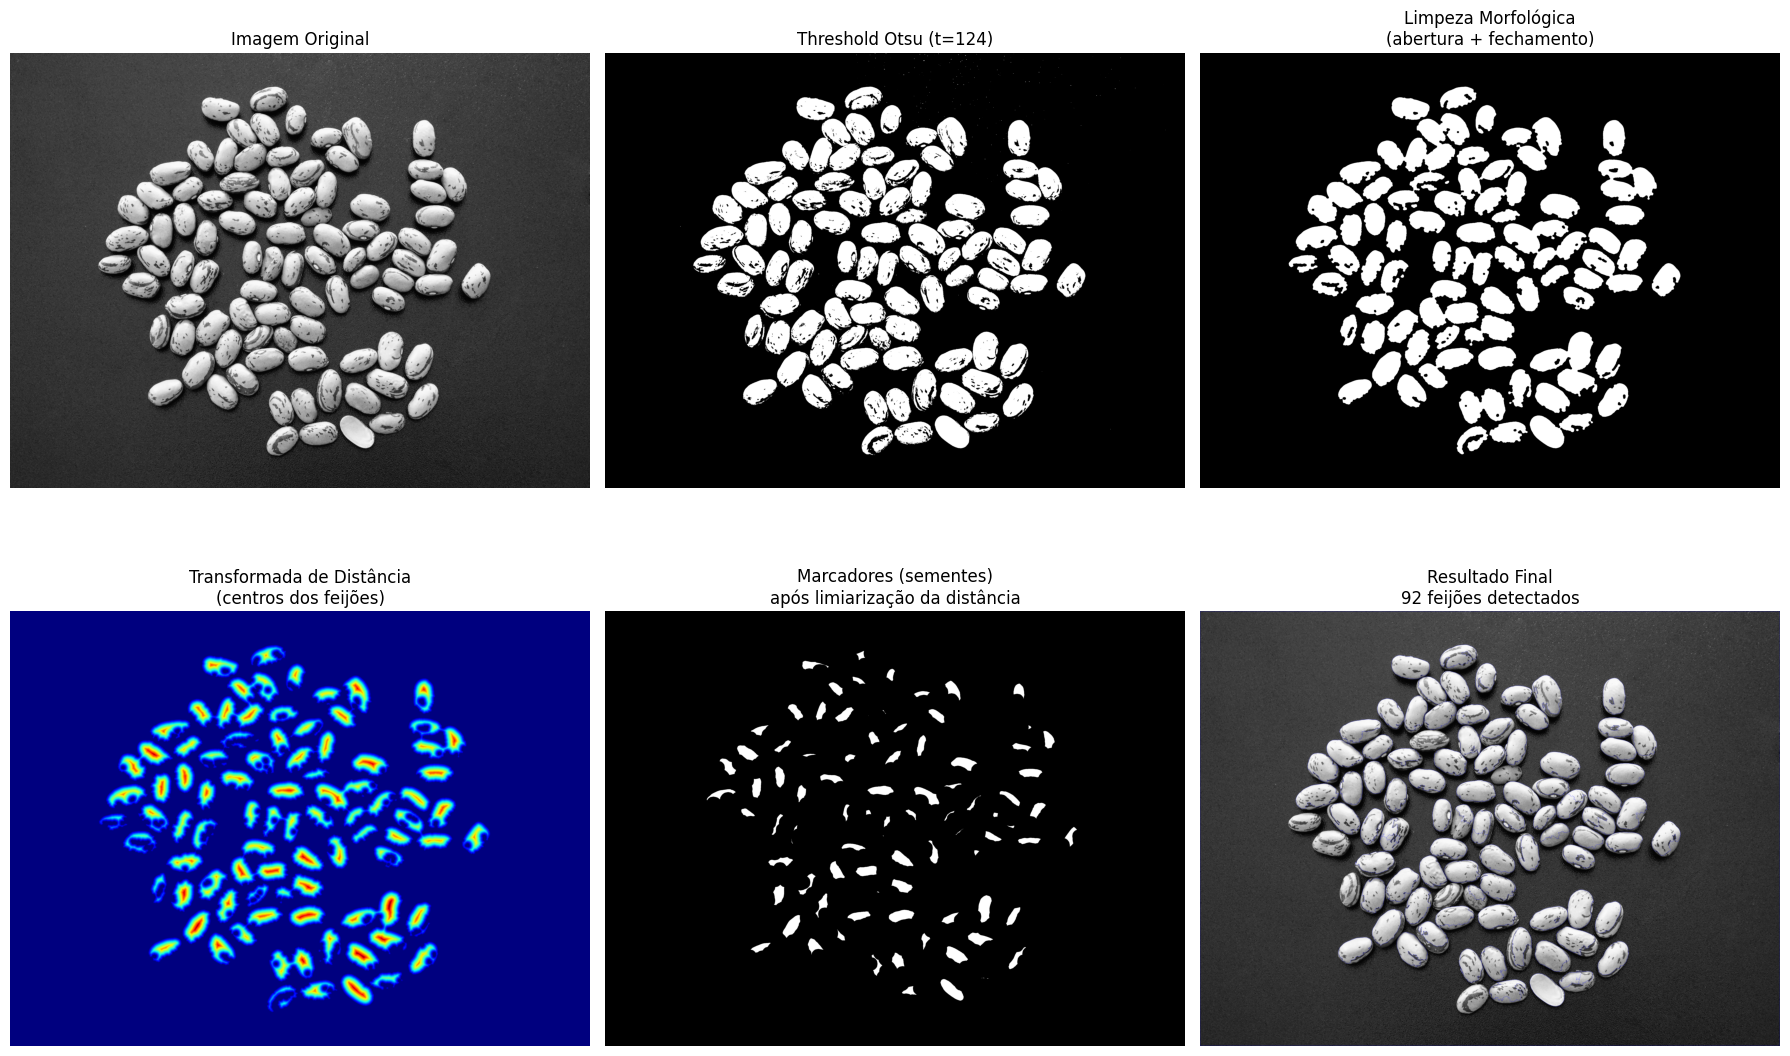

In [88]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

axs[0, 0].imshow(img4, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Imagem Original")

axs[0, 1].imshow(img4_bin, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title(f"Threshold Otsu (t={limiar_otsu:.0f})")

axs[0, 2].imshow(img4_limpa, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title("Limpeza Morfológica\n(abertura + fechamento)")

axs[1, 0].imshow(dist_norm, cmap='jet')
axs[1, 0].set_title("Transformada de Distância\n(centros dos feijões)")

axs[1, 1].imshow(frente_certa, cmap='gray')
axs[1, 1].set_title("Marcadores (sementes)\napós limiarização da distância")

img4_resultado = img4_color.copy()
img4_resultado[marcadores_final == -1] = [255, 0, 0] 
axs[1, 2].imshow(cv2.cvtColor(img4_resultado, cv2.COLOR_BGR2RGB))
axs[1, 2].set_title(f"Resultado Final\n{quantidade_feijoes} feijões detectados")

for ax in axs.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

5. Utilize a transformada hit or miss para localizar o logotipo da UFU. Escolha um deles

In [89]:
img5 = cv2.imread("logotipos.png", cv2.IMREAD_GRAYSCALE)

1. BINARIZAÇÃO DA IMAGEM

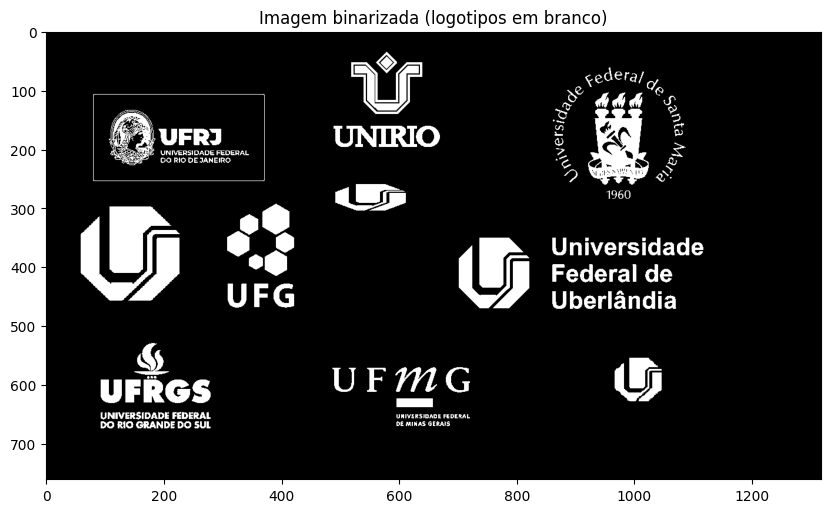

In [90]:
_, img5_bin = cv2.threshold(img5, 200, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 6))
plt.imshow(img5_bin, cmap='gray', vmin=0, vmax=255)
plt.title("Imagem binarizada (logotipos em branco)")
plt.show()

2. EXTRAÇÃO DO TEMPLATE

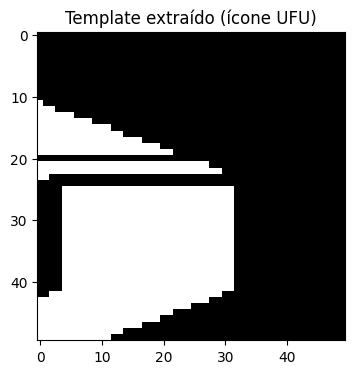

In [91]:

y1, y2 = 250, 300
x1, x2 = 580, 630

template = img5_bin[y1:y2, x1:x2]

plt.figure(figsize=(4, 4))
plt.imshow(template, cmap='gray', vmin=0, vmax=255)
plt.title("Template extraído (ícone UFU)")
plt.show()

3. CONSTRUÇÃO DO HIT-OR-MISS

In [92]:
kernel_hitmiss = np.where(template == 255, 1, -1).astype(np.int8)

print("Kernel Hit-or-Miss (formato do template):")
print(kernel_hitmiss)
print(f"Dimensões do kernel: {kernel_hitmiss.shape}")

resultado_hitmiss = cv2.morphologyEx(img5_bin, cv2.MORPH_HITMISS, kernel_hitmiss)

Kernel Hit-or-Miss (formato do template):
[[-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 ...
 [ 1  1  1 ... -1 -1 -1]
 [ 1  1  1 ... -1 -1 -1]
 [ 1  1  1 ... -1 -1 -1]]
Dimensões do kernel: (50, 50)


4. LOCALIZAÇÃO DAS OCORRÊNCIAS

In [93]:
coords_matches = np.column_stack(np.where(resultado_hitmiss == 255))
print(f"\nNúmero de ocorrências encontradas: {len(coords_matches)}")
print("Coordenadas (linha, coluna) das ocorrências:")
print(coords_matches)


Número de ocorrências encontradas: 1
Coordenadas (linha, coluna) das ocorrências:
[[275 605]]


5. VISUALIZAÇÃO

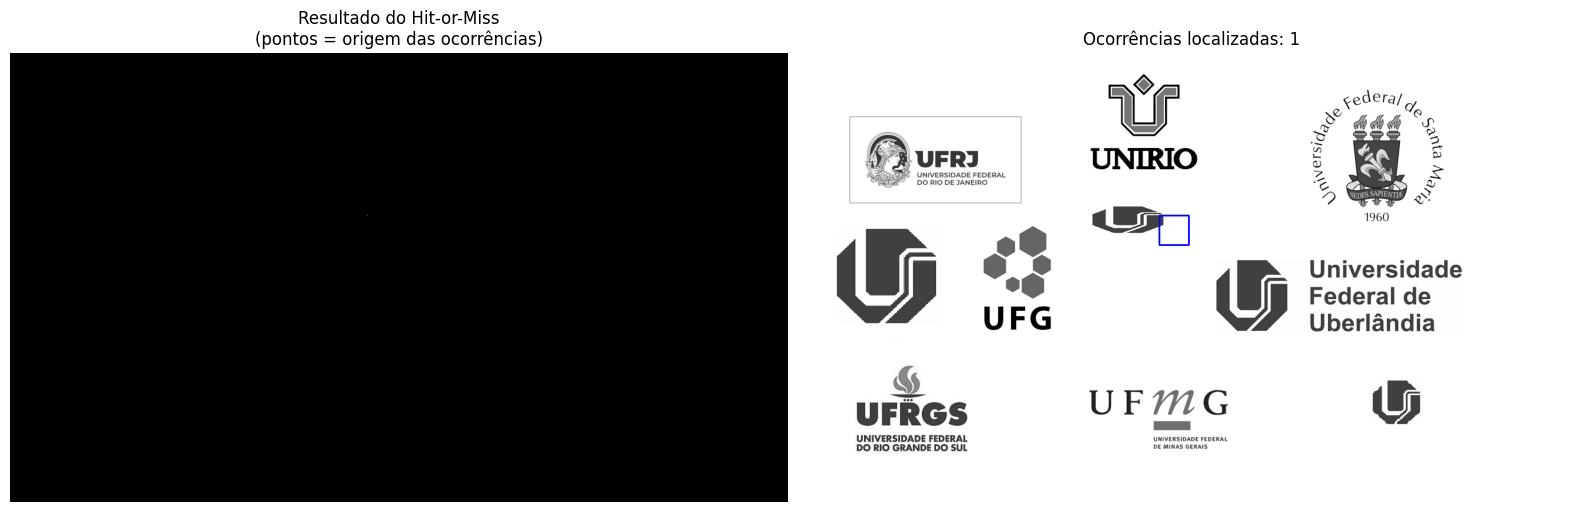

In [94]:
img5_color = cv2.cvtColor(img5, cv2.COLOR_GRAY2BGR)

h_template, w_template = template.shape
for (ly, lx) in coords_matches:
    cv2.rectangle(
        img5_color,
        (lx, ly),
        (lx + w_template, ly + h_template),
        (255, 0, 0),  # retângulo vermelho
        2
    )

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].imshow(resultado_hitmiss, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Resultado do Hit-or-Miss\n(pontos = origem das ocorrências)")

axs[1].imshow(cv2.cvtColor(img5_color, cv2.COLOR_BGR2RGB))
axs[1].set_title(f"Ocorrências localizadas: {len(coords_matches)}")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()